In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('../data/raw'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Data Dictionary

| Variable   | Definition                          | Key                                      |
|------------|-------------------------------------|------------------------------------------|
| survival   | Survival                            | 0 = No, 1 = Yes                          |
| pclass     | Ticket class                        | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex        | Sex                                 |                                          |
| age        | Age in years                        |                                          |
| sibsp      | # of siblings / spouses aboard      |                                          |
| parch      | # of parents / children aboard      |                                          |
| ticket     | Ticket number                       |                                          |
| fare       | Passenger fare                      |                                          |
| cabin      | Cabin number                        |                                          |
| embarked   | Port of Embarkation                 | C = Cherbourg, Q = Queenstown, S = Southampton |

---

# Variable Notes

- **pclass:** A proxy for socio-economic status (SES)  
  - 1st = Upper  
  - 2nd = Middle  
  - 3rd = Lower  

- **age:**  
  - Age is fractional if less than 1.  
  - If the age is estimated, it is in the form of `xx.5`.  

- **sibsp:** Family relations defined as:  
  - Sibling = brother, sister, stepbrother, stepsister  
  - Spouse = husband, wife (mistresses and fiancés were ignored)  

- **parch:** Family relations defined as:  
  - Parent = mother, father  
  - Child = daughter, son, stepdaughter, stepson  
  - Some children travelled only with a nanny, therefore `parch = 0` for them.  


In [7]:
training_data = pd.read_csv('../data/raw/train.csv')
training_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
def titanic_feature_engineering(df):
    # Extract Title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False).fillna('Unknown')
    # Group rare titles
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 
                                       'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # Create Family Size feature
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # Drop columns that aren't useful for the model
    df=df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')
    return df

In [9]:
# let's try and drop the non null columns and then remove the Cabin because there's too few of those values.

training_data = titanic_feature_engineering(training_data)
training_data=training_data.dropna(subset=['Age'])

<Axes: title={'center': 'Fare'}, xlabel='Survived'>

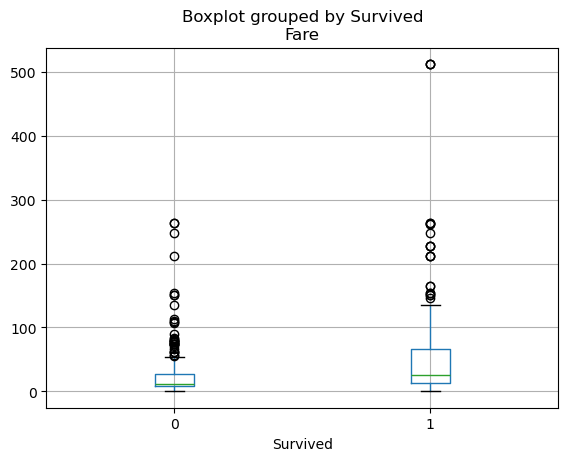

In [10]:
training_data.boxplot(column='Fare', by='Survived')

In [11]:
# Let's do test, train, splitting again... need some class impoorts
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns 

# Preprocessing 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

# Classification models 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 

# Metrics & evaluation 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay

In [12]:
y=training_data['Survived']
X=training_data.drop(columns=['Survived'])
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
def eval_and_plot(model_type, pipeline, param_grid):
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_pipe = grid_search.best_estimator_
    y_prob=best_pipe.predict_proba(X_test)[:, 1]
    y_pred = best_pipe.predict(X_test)
    
    # SOME STATS
    print('\n\nParameters and Results Data for ', model_type)
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Score:", grid_search.best_score_)
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))
    print("Classification Report:\n\n", classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    
    cm=confusion_matrix(y_test, y_pred)
    disp=ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix for: "+model_type)
    plt.show()
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label='ROC Curve')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for "+model_type)
    plt.legend()
    plt.show()
    
    # 2. Get feature names
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    model = best_pipe.named_steps['classifier']
    
    # 3. Check for Tree-based Importance
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=feature_names)
        importances.sort_values(ascending=False).plot(kind='bar', title="Feature Importances")
        print("Feature Importances:\n", importances.sort_values(ascending=False))
    
    # 4. Check for Linear Coefficients (Logistic Regression)
    elif hasattr(model, 'coef_'):
        # .flatten() or [0] converts the 2D array to 1D for the DataFrame
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': model.coef_.flatten() 
        })
        coef_df['abs_coef'] = coef_df['coefficient'].abs()
        coef_df = coef_df.sort_values(by='abs_coef', ascending=False)
        
        coef_df.set_index('feature')['coefficient'].plot(kind='bar', title="Coefficients")
        print("Top Coefficients:\n", coef_df)
    
    else:
        print("Model type does not support standard importance/coefficients.")
    
    return grid_search.best_estimator_

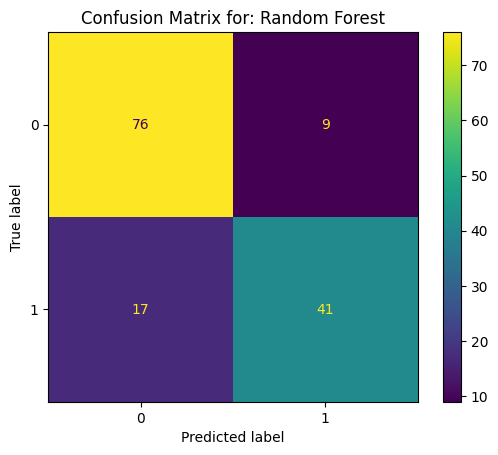



Parameters and Results Data for  Random Forest
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 300}
Best CV Score: 0.8335774218154082
Accuracy Score:  0.8181818181818182
Classification Report:

               precision    recall  f1-score   support

           0       0.82      0.89      0.85        85
           1       0.82      0.71      0.76        58

    accuracy                           0.82       143
   macro avg       0.82      0.80      0.81       143
weighted avg       0.82      0.82      0.82       143

ROC AUC: 0.8685598377281948


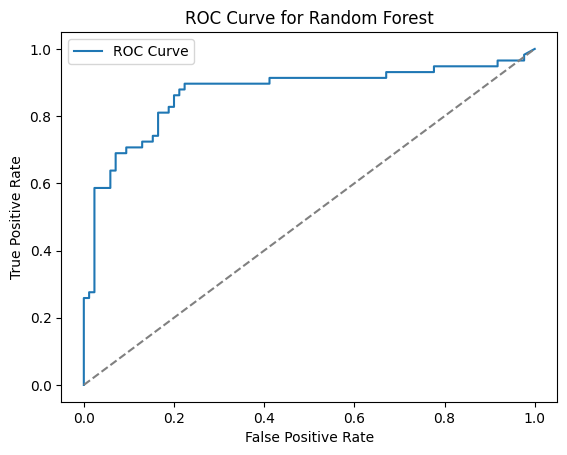

Feature Importances
num__Fare            0.116412
num__Age             0.079456
num__FamilySize      0.062141
cat__Pclass_1        0.043237
cat__Pclass_2        0.028377
cat__Pclass_3        0.092715
cat__Sex_female      0.159303
cat__Sex_male        0.151612
cat__Embarked_C      0.015465
cat__Embarked_Q      0.004376
cat__Embarked_S      0.012037
cat__Embarked_nan    0.000034
cat__Title_Master    0.014193
cat__Title_Miss      0.033876
cat__Title_Mr        0.150284
cat__Title_Mrs       0.028801
cat__Title_Rare      0.007681
dtype: float64


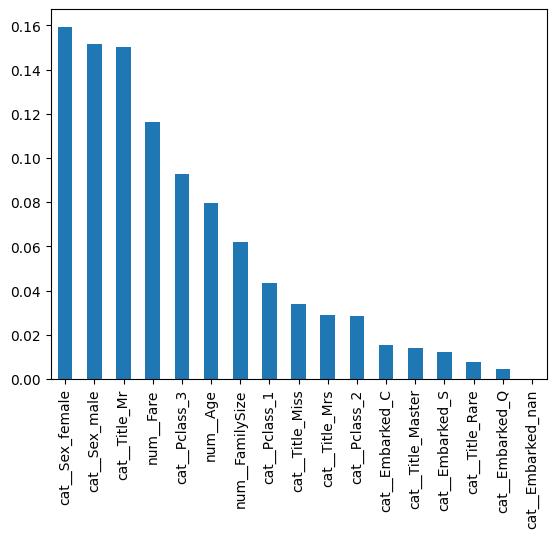

In [18]:
# We have successfully encoded the categorical values, so we need one simple standard scaler for age and fare
# START WITH RANDOM FOREST
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

param_grid = {
    'classifier__n_estimators': [150, 200, 250, 300],
    'classifier__max_depth': [4, 5, 6, 7, 8],
    'classifier__min_samples_split': [2, 3, 4]
}

fitted=eval_and_plot('Random Forest', pipeline, param_grid)


# Random Forest Results

## Round 1:

#### Parameters and Results Data for Random Forest:

- Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
- Best CV Score: 0.7004576659038901
- Accuracy Score:  0.6783216783216783

#### Classification Report:

               precision    recall  f1-score   support

           0       0.71      0.79      0.74        85
           1       0.62      0.52      0.57        58
           
    accuracy                           0.68       143
    macro avg       0.67      0.65      0.66       143
    weighted avg    0.67      0.68      0.67       143

---

## Round 2:

#### Parameters and Results Data for  Random Forest

- Best Parameters: {'classifier__max_depth': 4, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 150}
- Best CV Score: 0.7109839816933639
- Accuracy Score:  0.7062937062937062
- ROC AUC: 0.6895537525354969

#### Classification Report:

               precision    recall  f1-score   support

           0       0.71      0.85      0.77        85
           1       0.69      0.50      0.58        58

    accuracy                           0.71       143
    macro avg       0.70      0.67      0.68       143
    weighted avg    0.70      0.71      0.70       143

---

## Round 3(After Doing One Hot Encoding and Feature Eng):

#### Parameters and Results Data for  Random Forest

- Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 300}
- Best CV Score: 0.8335774218154082
- Accuracy Score:  0.8181818181818182
- ROC AUC: 0.8685598377281948

#### Classification Report:

               precision    recall  f1-score   support

           0       0.82      0.89      0.85        85
           1       0.82      0.71      0.76        58

    accuracy                           0.82       143
    macro avg       0.82      0.80     0.81       143
    weighted avg    0.82      0.82     0.82       143



Parameters and Results Data for  Logistic Regression
Best Parameters: {'classifier__C': 0.15, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV Score: 0.8125705568268498
Accuracy Score:  0.8461538461538461
Classification Report:

               precision    recall  f1-score   support

           0       0.87      0.87      0.87        85
           1       0.81      0.81      0.81        58

    accuracy                           0.85       143
   macro avg       0.84      0.84      0.84       143
weighted avg       0.85      0.85      0.85       143

ROC AUC: 0.8827586206896552


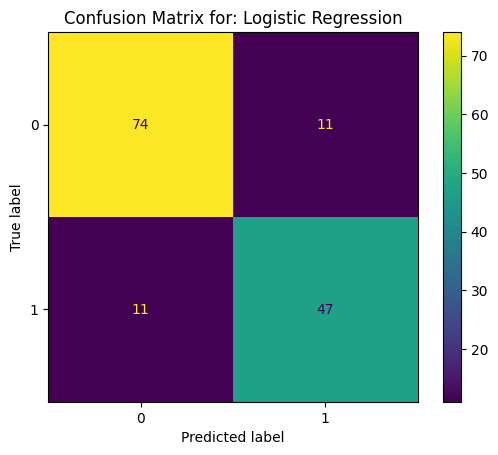

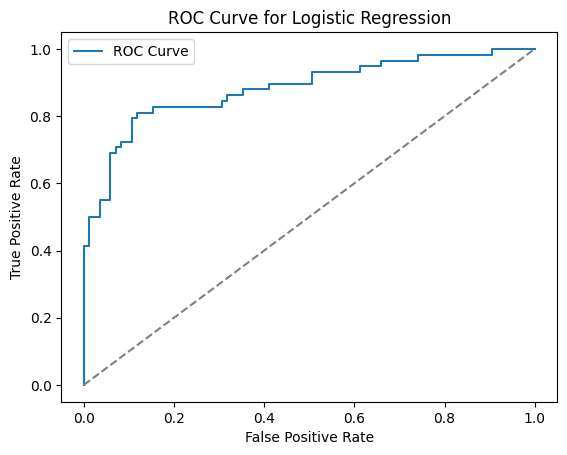

Top Coefficients:
               feature  coefficient  abs_coef
14      cat__Title_Mr    -0.905004  0.905004
3       cat__Pclass_1     0.817012  0.817012
5       cat__Pclass_3    -0.757266  0.757266
6     cat__Sex_female     0.746315  0.746315
12  cat__Title_Master     0.592515  0.592515
7       cat__Sex_male    -0.581089  0.581089
15     cat__Title_Mrs     0.568096  0.568096
1            num__Age    -0.408661  0.408661
2     num__FamilySize    -0.384274  0.384274
8     cat__Embarked_C     0.377198  0.377198
0           num__Fare     0.210353  0.210353
16    cat__Title_Rare    -0.200063  0.200063
10    cat__Embarked_S    -0.125060  0.125060
13    cat__Title_Miss     0.109681  0.109681
4       cat__Pclass_2     0.105480  0.105480
9     cat__Embarked_Q    -0.104176  0.104176
11  cat__Embarked_nan     0.017265  0.017265


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Fare', 'Age',
                                                   'FamilySize']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', LogisticRegression(C=0.15, solver='liblinear'))])

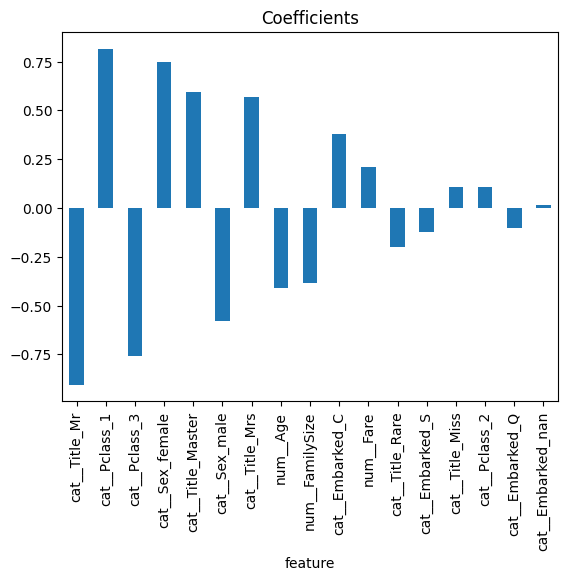

In [23]:
## Logistic Regression Next
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

param_grid = {
    'classifier__C': [0.05, 0.07, 0.1, 0.12, 0.15],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

eval_and_plot('Logistic Regression', pipeline, param_grid)

# Logistic Regression Results

## Round 1:

#### Parameters and Results Data for  Logistic Regression

- Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
- Best CV Score: 0.661998474446987
- Accuracy Score:  0.6363636363636364
- ROC AUC: 0.7164300202839757

#### Classification Report:

               precision    recall  f1-score   support

           0       0.65      0.86      0.74        85
           1       0.60      0.31      0.41        58

    accuracy                           0.64       143
    macro avg       0.62      0.58     0.57       143
    weighted avg    0.63      0.64     0.60       143

---

## Round 2: 

#### Parameters and Results Data for  Logistic Regression

- Best Parameters: {'classifier__C': 0.05, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
- Best CV Score: 0.6672463768115942
- Accuracy Score:  0.6643356643356644
- ROC AUC: 0.7028397565922919

#### Classification Report:

               precision    recall  f1-score   support

           0       0.66      0.88      0.76        85
           1       0.67      0.34      0.45        58

    accuracy                           0.66       143
    macro avg       0.67      0.61      0.61       143
    weighted avg    0.66      0.66      0.63       143

---
## Round 3 (Post Feature Eng):

#### Parameters and Results Data for  Logistic Regression

- Best Parameters: {'classifier__C': 0.15, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
- Best CV Score: 0.8125705568268498
- Accuracy Score:  0.8461538461538461
- ROC AUC: 0.8827586206896552

#### Classification Report:

               precision    recall  f1-score   support

           0       0.87      0.87      0.87        85
           1       0.81      0.81      0.81        58

    accuracy                           0.85       143
    macro avg       0.84      0.84     0.84       143
    weighted avg    0.85      0.85     0.85       143

In [ ]:
## Support Vector Machine Next!
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])

param_grid = {
    'classifier__C': [0.5, 0.8, 1, 1.2, 1.5],
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__gamma': [0.5, 1, 1.5, 2, 5]
}

eval_and_plot('Support Vector Machine [SVC]', pipeline, param_grid)

# SVM Results

## Round 1:

#### Parameters and Results Data for  Support Vector Machine [SVC]

- Best Parameters: {'classifier__C': 1, 'classifier__gamma': 1, 'classifier__kernel': 'rbf'}
- Best CV Score: 0.6934706331045003
- Accuracy Score:  0.7062937062937062
- ROC AUC: 0.698580121703854

#### Classification Report:

               precision    recall  f1-score   support

           0       0.70      0.87      0.78        85
           1       0.71      0.47      0.56        58

    accuracy                           0.71       143
    macro avg       0.71      0.67      0.67       143
    weighted avg    0.71      0.71      0.69       143

---

## Round 2: 

#### Parameters and Results Data for  Support Vector Machine [SVC]

- Best Parameters: {'classifier__C': 0.5, 'classifier__gamma': 1, 'classifier__kernel': 'rbf'}
- Best CV Score: 0.6952250190694127
- Accuracy Score:  0.7202797202797203
- ROC AUC: 0.6981744421906693

#### Classification Report:

               precision    recall  f1-score   support

           0       0.72      0.87      0.79        85
           1       0.72      0.50      0.59        58

    accuracy                           0.72       143
    macro avg       0.72      0.69      0.69       143
    weighted avg    0.72      0.72      0.71       143

---



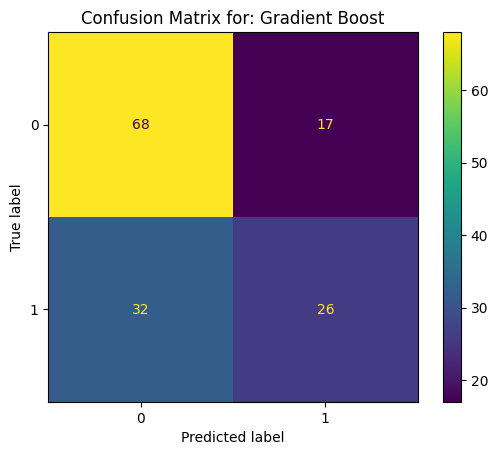



Parameters and Results Data for  Gradient Boost
Best Parameters: {'classifier__learning_rate': 0.012, 'classifier__max_depth': 4, 'classifier__n_estimators': 110}
Best CV Score: 0.705720823798627
Accuracy Score:  0.6573426573426573
Classification Report:

               precision    recall  f1-score   support

           0       0.68      0.80      0.74        85
           1       0.60      0.45      0.51        58

    accuracy                           0.66       143
   macro avg       0.64      0.62      0.62       143
weighted avg       0.65      0.66      0.65       143



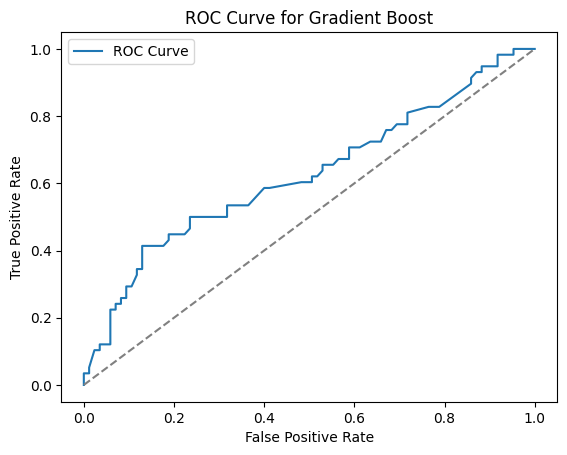

ROC AUC: 0.624949290060852


In [18]:
## GBoost Next~!
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

param_grid = {
    'classifier__n_estimators': [80, 90, 100, 110, 120],
    'classifier__max_depth': [1, 2, 3, 4],
    'classifier__learning_rate': [0.005, 0.007, 0.01, 0.012, 0.015]
}

eval_and_plot('Gradient Boost', pipeline, param_grid)

# Gradient Boost Results

## Round 1:

#### Parameters and Results Data for  Gradient Boost

- Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
- Best CV Score: 0.7005034324942792
- Accuracy Score:  0.6993006993006993
- ROC AUC: 0.6488843813387424

#### Classification Report:

               precision    recall  f1-score   support

           0       0.70      0.87      0.77        85
           1       0.70      0.45      0.55        58

    accuracy                           0.70       143
    macro avg       0.70      0.66      0.66       143
    weighted avg    0.70      0.70      0.68       143

---

## Round 2:

#### Parameters and Results Data for  Gradient Boost

- Best Parameters: {'classifier__learning_rate': 0.012, 'classifier__max_depth': 4, 'classifier__n_estimators': 110}
- Best CV Score: 0.705720823798627
- Accuracy Score:  0.6573426573426573
- ROC AUC: 0.624949290060852

#### Classification Report:

               precision    recall  f1-score   support

           0       0.68      0.80      0.74        85
           1       0.60      0.45      0.51        58

    accuracy                           0.66       143
    macro avg       0.64      0.62      0.62      143
    weighted avg    0.65      0.66      0.65       143

---

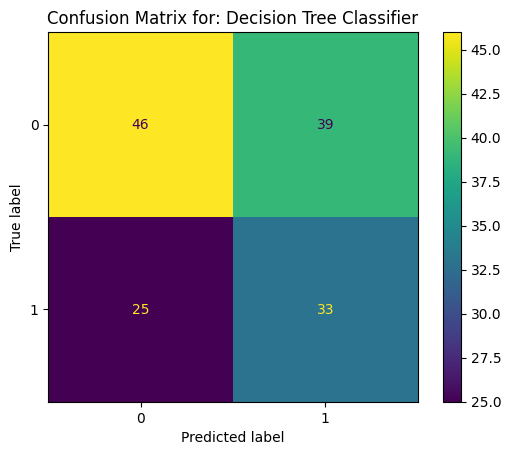



Parameters and Results Data for  Decision Tree Classifier
Best Parameters: {'classifier__criterion': 'log_loss', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt'}
Best CV Score: 0.6812204424103737
Accuracy Score:  0.5524475524475524
Classification Report:

               precision    recall  f1-score   support

           0       0.65      0.54      0.59        85
           1       0.46      0.57      0.51        58

    accuracy                           0.55       143
   macro avg       0.55      0.56      0.55       143
weighted avg       0.57      0.55      0.56       143



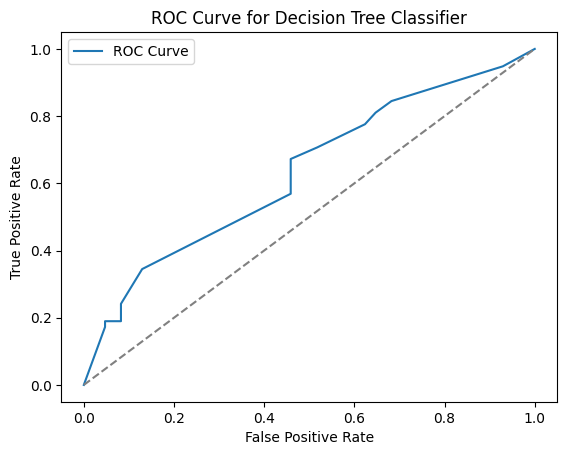

ROC AUC: 0.6322515212981745


In [19]:
## DecisionTree Next
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

param_grid = {
    'classifier__criterion': ['log_loss'],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__max_features': ['sqrt', 'log2']
}

eval_and_plot('Decision Tree Classifier', pipeline, param_grid)

# Decision Tree Classifier Results

## Round 1:

#### Parameters and Results Data for  Decision Tree Classifier

- Best Parameters: {'classifier__criterion': 'log_loss', 'classifier__max_depth': 5, 'classifier__max_features': 'log2'}
- Best CV Score: 0.6689702517162471
- Accuracy Score:  0.6643356643356644
- ROC AUC: 0.6779918864097363

#### Classification Report:

               precision    recall  f1-score   support

           0       0.70      0.76      0.73        85
           1       0.60      0.52      0.56        58

    accuracy                           0.66       143
    macro avg       0.65      0.64      0.64       143
    weighted avg    0.66      0.66      0.66       143

---

## Round 2:

#### Parameters and Results Data for  Decision Tree Classifier

- Best Parameters: {'classifier__criterion': 'log_loss', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt'}
- Best CV Score: 0.6812204424103737
- Accuracy Score:  0.5524475524475524
- ROC AUC: 0.6322515212981745

#### Classification Report:

               precision    recall  f1-score   support

           0       0.65      0.54      0.59        85
           1       0.46      0.57      0.51        58

    accuracy                           0.55       143
    macro avg       0.55      0.56      0.55       143
    weighted avg    0.57      0.55      0.56       143

---


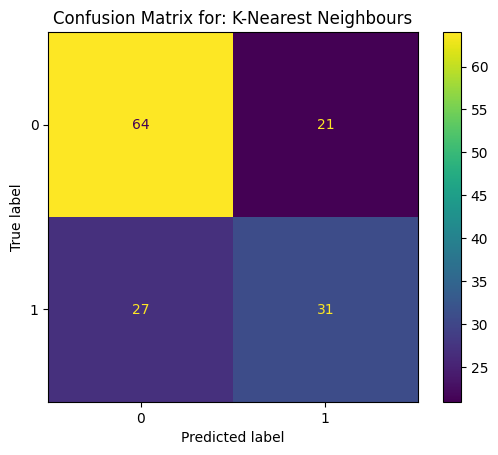



Parameters and Results Data for  K-Nearest Neighbours
Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 10, 'classifier__weights': 'uniform'}
Best CV Score: 0.6865446224256293
Accuracy Score:  0.6643356643356644
Classification Report:

               precision    recall  f1-score   support

           0       0.70      0.75      0.73        85
           1       0.60      0.53      0.56        58

    accuracy                           0.66       143
   macro avg       0.65      0.64      0.65       143
weighted avg       0.66      0.66      0.66       143



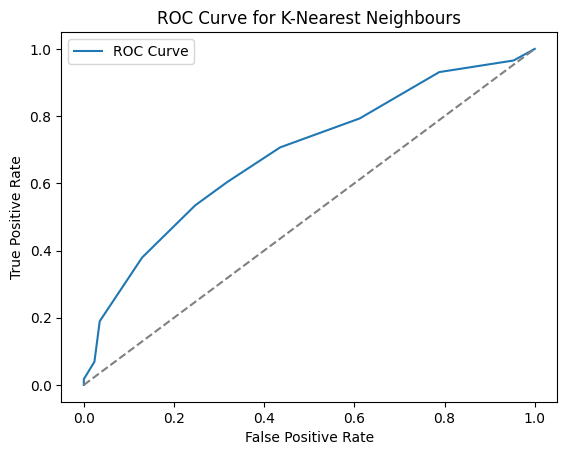

ROC AUC: 0.6872210953346856


In [20]:
## KNN Next!
numeric_features=['Fare', 'Age', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'classifier__n_neighbors': [9, 10, 11, 12, 13],
    'classifier__weights': ['uniform'],
    'classifier__metric': ['euclidean']
}

eval_and_plot('K-Nearest Neighbours', pipeline, param_grid)

# KNN Results

#### Parameters and Results Data for  K-Nearest Neighbours

- Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
- Best CV Score: 0.6812509534706331
- Accuracy Score:  0.6783216783216783
- ROC AUC: 0.6833671399594321

#### Classification Report:

               precision    recall  f1-score   support

           0       0.72      0.75      0.74        85
           1       0.61      0.57      0.59        58

    accuracy                           0.68       143
    macro avg       0.67      0.66      0.66       143
    weighted avg    0.68      0.68      0.68       143

---

## Round 2:

#### Parameters and Results Data for  K-Nearest Neighbours

- Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 10, 'classifier__weights': 'uniform'}
- Best CV Score: 0.6865446224256293
- Accuracy Score:  0.6643356643356644
- ROC AUC: 0.6872210953346856

#### Classification Report:

               precision    recall  f1-score   support

           0       0.70      0.75      0.73        85
           1       0.60      0.53      0.56        58

    accuracy                           0.66       143
    macro avg       0.65      0.64      0.65       143
    weighted avg    0.66      0.66      0.66       143

---